# Machine Learning

## HSE, 2024-25

### Exam. Variant 1

Completed by: _(enter your last name and first name)_

### Submission Format


Save your work file in .ipynb format and upload it via the link in telegram channel.

### About the task

Working with the file Wine Quality Red

You are provided with a dataset containing characteristics and quality ratings of red wine. The dataset consists of a single table.

The table contains summarized information on the chemical properties of the wine and its quality ratings: each row represents one wine sample, and the columns indicate attributes characterizing that sample.

The table includes the following columns:

- fixed acidity
- volatile acidity
- citric acid content
- residual sugar
- chloride content
- free sulfur dioxide
- total sulfur dioxide
- density
- pH level
- sulphate content
- alcohol content
- wine quality rating

Complete the following tasks with this dataset.

## Task 1. EDA (13 points)

In [46]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score



### 1.1 (1 point)

Carefully examine the features of the main table. Which feature might be of significant interest for the study and serve as the target variable here? Justify your answer.

Наиболее подходящий признак для целевой переменной это quality, так как на ее основе можно провести различное прогнозирование качества вина в зависимости от хим показателей

In [4]:
df = pd.read_csv("Wine Quality Red.csv",encoding='utf-8',sep=',')
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


### 1.2 (1 point)

Perform the EDA step related to handling missing values. (Are there any missing values in the data? If there are, fill all the missing values appropriately). Justify your actions.

In [10]:
df.shape

(1599, 12)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


как видим, все заполнены, нет пропущенных значений

### 1.3. (3 points)

Perform the EDA step related to correlations. (Determine which columns have a high correlation with the target variable, and identify any collinear features. Indicate whether this is good or bad for the subsequent analysis. Create a heatmap of correlations). Draw conclusions.

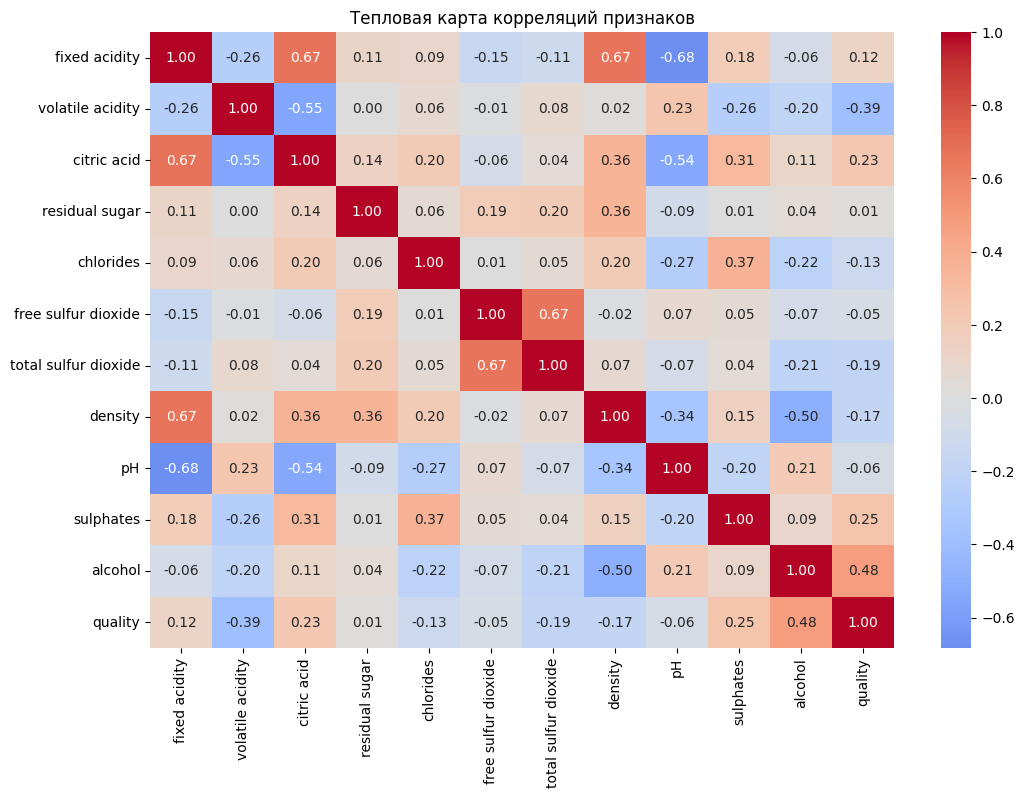

In [11]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt=".2f")
plt.title("Тепловая карта корреляций признаков")
plt.show()

Наша целевая переменная  quality  наиболее всего коррелирует с alcohol 0,48 и немного с sulphates 0,25 это положительная корреляция говорит о том , что чем выше качесво, тем чуть больше алкоголя содержится в вине и совсем чуть больше содержания сульфатов при росте качесва , volatile acidity -0,39 отрицательная корреляция , то есть чем выше качесво тем меньше кислотность(volatile acidity), так же есть отрицательная корреляция умеренная с total sulfur dioxide  -0,19. Как видно из корреляционой матрицы fixed acidity и citric acid  имеют большую корреляцию 0,67, а так же fixed acidity и pH -0,68 сильная отрицательная корреляция, так как уровень ph зависит от кислотности ,  free sulfur dioxide и total sulfur dioxide сильная положительная корреляция 0.67  так как одно включаетв себя другое . Так же density и alcohol -0,5, то есть алкоголь снижает плотность
еать несколько признаков которые можно удалить, в связи с сильной связью между собой например fixed acidity или ph,free sulfur dioxide удалить так как он входит в total sulfur dioxide
В итоге получается что на качесво вина влияют алкоголь, летучая кислотность , сульфаты и лимонная кислота.


### 1.4 (5 points)

Perform the EDA step related to visualizations. (Create at least 2 ***different*** types of significant visualizations within the framework of Univariate analysis and at least 2 different types within the framework of Multivariate analysis). Draw conclusions.

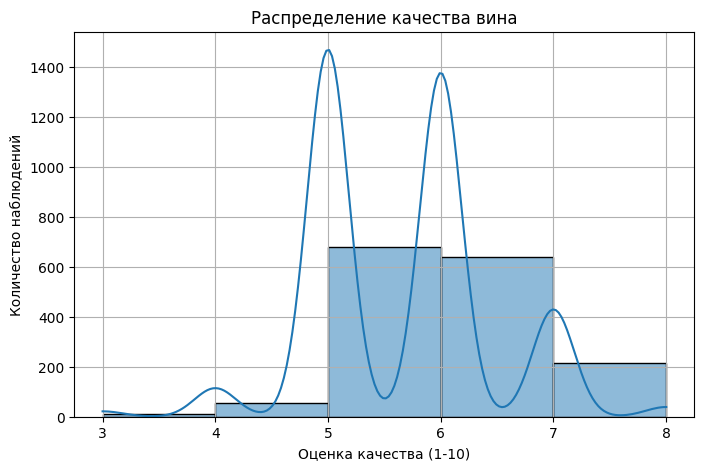

In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(df['quality'], bins=5,kde=True)
plt.title("Распределение качества вина")
plt.xlabel("Оценка качества (1-10)")
plt.ylabel("Количество наблюдений")
plt.grid()
plt.show()

Как видим из графига гистограммы распередения целевой переменной,качесво вина находится в среднем диапазоне 5 - 6 , то есть очень низкого качесва и очень высокого качества значения встречаются редко. Может быть из за какого то дисбаланса в классах   

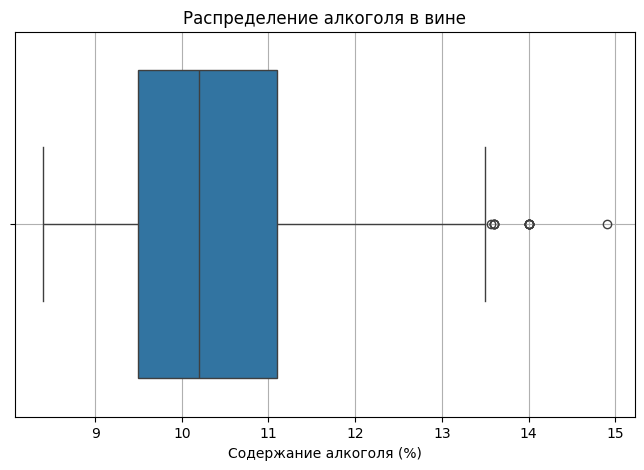

In [21]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['alcohol'])
plt.title("Распределение алкоголя в вине")
plt.xlabel("Содержание алкоголя (%)")
plt.grid()
plt.show()

как видим среднее содержание алкоголя в вине составляет 10 процентов. Так же можно заметить , что есть выбросы в зоне с очень большим содержанием алкоголя

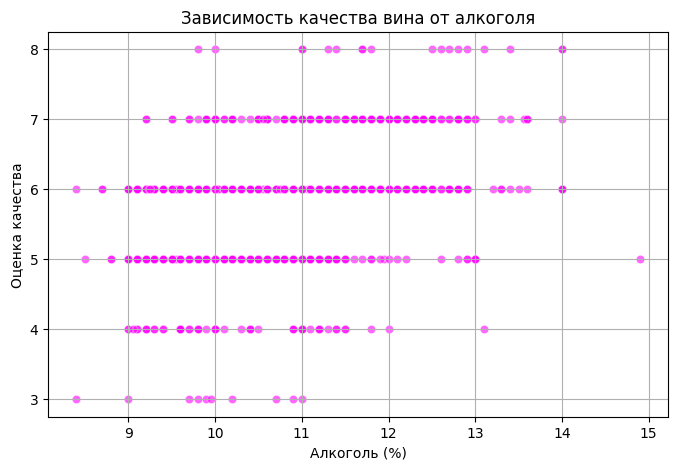

In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='alcohol', y='quality', data=df, alpha=0.6, color='fuchsia')
plt.title("Зависимость качества вина от алкоголя")
plt.xlabel("Алкоголь (%)")
plt.ylabel("Оценка качества")
plt.grid()
plt.show()

Как видно из графика зависимость качесва вина и алкоголя имеют зависимость чем больше алкоголя, тем выше качество вина. Есть так же некоторые значенгия где алкоголь высокий, но качесво маленькое, но это скорее исключение

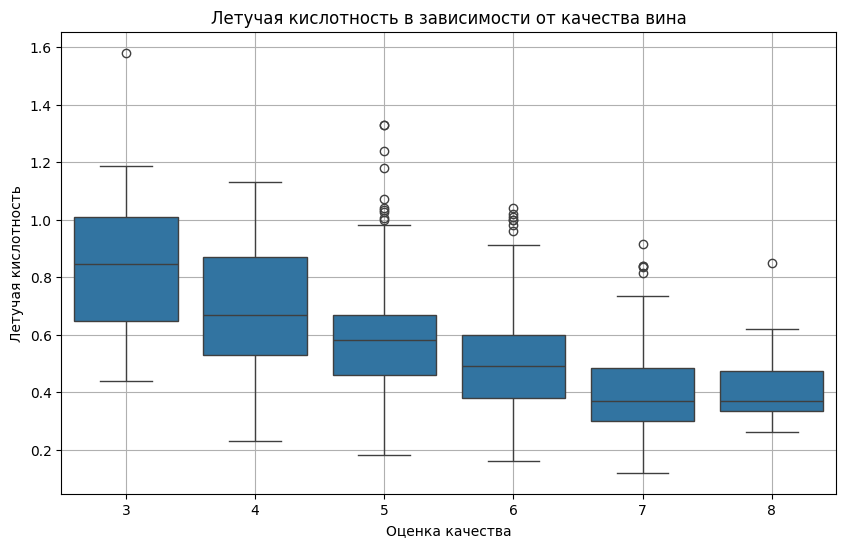

In [35]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='quality', y='volatile acidity', data=df)
plt.title("Летучая кислотность в зависимости от качества вина")
plt.xlabel("Оценка качества")
plt.ylabel("Летучая кислотность")
plt.grid()
plt.show()

как видим , что чем выше качесво , тем ниже уровень volatile acidity(летучая кислотность) То есть вина с качесвом 7 и 8 имеют самую маленькую кислотность. Так же видно что есть выбросы летучей кислотности на качесве 5,6,7,8

### 1.5 (3 points)

Perform the EDA step related to initial hypotheses. (Formulate at least two ***meaningful*** hypotheses about the data that you can make at the initial data analysis (EDA) stage and that may subsequently help in the ML stage).

1 гипотеза. Чем крепче вино, то есть чем больше в нем содержания алкоголя, тем оно вкуснее для потребителя, так как оценка качесва тоже выше . Как мы можем заметить из матрицы корреляции оценка качесва вина имеет относительно высокую положительную  корреляцию с алкоголем, то есть чем больше алкоголя, тем болше оценка качесва 2 гипотеза. Слишком мягкиме вина с низкой кислотностью, обычно хуже. Так как ph связано с кислотнотью отрицательной корреляцией -0,68. То есть слишком кислые вина не очень вкусные, а значит имеют меньше оценку качества

## Task 2. Machine Learning (32 points)

### 2.1 (5 points)

Create 3 different datasets: the original data; data with normalization; data with normalization and applied PCA.

Additionally, split the data into `train` and `test` in a 75% / 25% ratio and set the `seed` to `24062025`. What else should be considered when splitting the data?

*Hint*: You should end up with 8 arrays.

*Hint #2*: Should PCA be applied before or after splitting into `train` and `test`?

Justify all your actions!

In [42]:
x = df.drop('quality', axis=1)
y = df['quality']
#исходные данные
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.25, random_state=24062025)
#данные с нормализацией
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#нормализация и pca. PCA применяла после разделения на train и test , и обучала на тренировочных нормализованных данных, то есть уменьшила количество признаков

pca = PCA(n_components=0.95)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
print(X_train, X_test, y_train, y_test,X_train_scaled,X_test_scaled,X_train_pca,X_test_pca)


      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
609             6.3              0.36         0.19             3.2      0.075   
59              7.3              0.39         0.31             2.4      0.074   
1413            9.9              0.57         0.25             2.0      0.104   
565            12.7              0.60         0.49             2.8      0.075   
110             7.8              0.56         0.19             1.8      0.104   
...             ...               ...          ...             ...        ...   
379             8.3              0.42         0.38             2.5      0.094   
155             7.1              0.43         0.42             5.5      0.071   
1340            7.5              0.51         0.02             1.7      0.084   
699            11.8              0.38         0.55             2.1      0.071   
6               7.9              0.60         0.06             1.6      0.069   

      free sulfur dioxide  

### 2.2 (5 points)

Create, run, and train at least 3 different types of machine learning models. The machine learning models should be of different nature.

In [59]:
logr = LogisticRegression(max_iter=1000, random_state=24062025)
logr.fit(X_train_scaled, y_train)
y_pred_log = logr.predict(X_test_scaled)

print(f"Accuracy: {accuracy_score(y_test, y_pred_log)}")
print(f"F1-score: {f1_score(y_test, y_pred_log, average='weighted')}")

Accuracy: 0.575
F1-score: 0.5582855115481083


In [60]:
rand = RandomForestClassifier(n_estimators=100, random_state=24062025)
rand.fit(X_train_scaled, y_train)
y_pred_r = rand.predict(X_test_scaled)
print(f"Accuracy: {accuracy_score(y_test, y_pred_r)}")
print(f"F1-score: {f1_score(y_test, y_pred_r, average='weighted')}")

Accuracy: 0.72
F1-score: 0.7046687126219705


### 2.3 (6 points)

Make predictions with all your models on all 3 datasets (a total of 9 predictions).

Which quality metrics would be well-suited for this machine learning task? Choose at least two. Justify your choice.

Calculate these metrics for all predictions. Record the results in a `pd.DataFrame` table of size 6 by 3 (6 rows because there are 3 datasets and 2 metrics; 3 columns because there are 3 models).



### 2.4 (3 points)

Conduct a comparative analysis and comment on the results obtained in the previous section. Which algorithm performed best on which dataset and with which metric? Why do you think that is? Be sure to justify your answer.

### 2.5 (5 points)

For any two of your models, perform hyperparameter tuning using cross-validation. Try running the algorithm with the found optimal hyperparameters and compare the results. Draw conclusions.